# Text consistency exploration for a review → keyword / topic graph

**Goal.** Find every text inconsistency that would break the graph we plan to build. In that graph:

- each **Review** node links to **Keyword / term** nodes and **Topic / theme** nodes;
- one real-world concept should map to **exactly one node**;
- noise (markup, emoji, IDs, typos) should not create nodes;
- each piece of text should be counted **once per review**.

This notebook only **finds and measures** the problems. It does not build the preprocessing pipeline. Each section ends with an **Implication** line, and section 15 collects them into a single table of candidate transformations for the preprocessing script.

The extraction approach (an LLM, or classic NLP such as spaCy or regex) is not decided yet. So each issue is tagged with which approach it matters for.

**Sections**
1. Setup
2. Encoding and markup
3. Title vs body: double counting
4. Language labels
5. Brand-name variants ("Trustpilot")
6. Casing
7. Punctuation and typography
8. Non-word tokens: emoji, URLs, numbers
9. Diacritics: what is safe to fold
10. Spelling errors
11. Morphology: inflection, stemming and compounds
12. Stopwords and hub terms
13. Same concept, many languages
14. Negation
15. Low-content reviews
16. Summary: inconsistencies → candidate transformations

## 1. Setup

In [1]:
import html
import re
import unicodedata
from collections import Counter, defaultdict
from pathlib import Path

import warnings

import emoji
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import nltk
import numpy as np
import pandas as pd
from lingua import LanguageDetectorBuilder
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer

nltk.download("stopwords", quiet=True)
warnings.filterwarnings("ignore", message="This pattern is interpreted as a regular expression")
pd.set_option("display.max_colwidth", 140)
pd.set_option("display.width", 200)

ROOT = Path.cwd() if (Path.cwd() / "pyproject.toml").exists() else Path.cwd().parent
DATA = ROOT / "Data_Advisory_Random_Sample_tp_2021 (3) (1).csv"

SURFACE, INK, INK_2, MUTED, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#898781", "#e1e0d9"
BLUE, ORANGE = "#2a78d6", "#eb6834"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "figure.dpi": 110, "font.size": 10,
    "text.color": INK, "axes.labelcolor": INK_2, "axes.titlecolor": INK,
    "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlelocation": "left", "axes.titlepad": 12,
    "axes.edgecolor": "#c3c2b7", "axes.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6, "axes.axisbelow": True,
    "xtick.color": MUTED, "ytick.color": MUTED, "xtick.labelcolor": INK_2, "ytick.labelcolor": INK_2,
    "legend.frameon": False, "lines.linewidth": 2,
})

# Word tokens: runs of letters in any script, with an optional inner apostrophe (don't, don’t, l'avis).
TOKEN_RE = re.compile(r"[^\W\d_]+(?:['’][^\W\d_]+)*")

# Languages with both an NLTK stopword list and a Snowball stemmer - about 98% of the data.
NLTK_LANG = {"en": "english", "de": "german", "fr": "french", "da": "danish", "it": "italian", "nl": "dutch",
             "es": "spanish", "sv": "swedish", "pt": "portuguese", "no": "norwegian", "ru": "russian", "fi": "finnish"}


def hbar(series, title, xlabel=None, color=BLUE, pct=False, figsize=(8, 3.6)):
    # Horizontal bar chart in the notebook's style, largest at the top, value labels at the bar end.
    fig, ax = plt.subplots(figsize=figsize)
    s = series[::-1]
    bars = ax.barh(s.index.astype(str), s.values, color=color, height=0.6)
    ax.bar_label(bars, labels=[f"{v:.1%}" if pct else f"{v:,}" for v in s.values], padding=3, fontsize=8.5, color=INK_2)
    if pct:
        ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=0))
    ax.grid(axis="y", visible=False)
    ax.set_xlim(0, s.max() * 1.15)
    ax.set_title(title)
    if xlabel:
        ax.set_xlabel(xlabel)
    plt.tight_layout()
    plt.show()

In [2]:
raw = pd.read_csv(DATA)
raw["language"] = raw["language"].replace({"nb": "no"})  # same language (Norwegian Bokmål), two codes

# Each section starts from the raw text, plus only the fixes earlier sections have shown are needed,
# so every issue is measured on its own.
title_raw = raw["Title"].fillna("")
body_raw = raw["Text"].fillna("")
title = title_raw.map(html.unescape)
body = body_raw.map(html.unescape)
lang = raw["language"]
stars = raw["stars"]
both = pd.concat([title, body], ignore_index=True)
print(f"{len(raw):,} reviews, {raw['language'].nunique()} language codes")

10,000 reviews, 41 language codes


## 2. Encoding and markup

The raw text arrives HTML-escaped. If this isn't fixed first, `&#233;` turns into the tokens `233`, or `é` disappears, depending on the tokenizer. Either way the same word ends up as different keyword nodes depending on where the review came from.

In [3]:
entity_re = r"&#?\w+;"
ents = Counter(m for s in pd.concat([title_raw, body_raw]) for m in re.findall(entity_re, s))
ent_tbl = pd.DataFrame(
    [(e, html.unescape(e), unicodedata.name(html.unescape(e), "?"), n) for e, n in ents.most_common(15)],
    columns=["entity", "decoded", "unicode name", "occurrences"])
print(f"Reviews with an entity: title {title_raw.str.contains(entity_re).sum():,}, "
      f"body {body_raw.str.contains(entity_re).sum():,}")
double_escaped = pd.concat([title_raw, body_raw]).str.contains(r"&amp;#?\w+;").sum()
print(f"Distinct entities: {len(ents)}   Double-escaped (&amp;#… / &amp;quot;): {double_escaped}")
print(f"Entities left after one html.unescape pass: {both.str.contains(entity_re).sum()}")
ent_tbl

Reviews with an entity: title 2,127, body 4,319
Distinct entities: 181   Double-escaped (&amp;#… / &amp;quot;): 0
Entities left after one html.unescape pass: 0


,entity,decoded,unicode name,occurrences
0,&#39;,',APOSTROPHE,3468
1,&#233;,é,LATIN SMALL LETTER E WITH ACUTE,2952
2,&#229;,å,LATIN SMALL LETTER A WITH RING ABOVE,1936
3,&#228;,ä,LATIN SMALL LETTER A WITH DIAERESIS,1486
4,&#246;,ö,LATIN SMALL LETTER O WITH DIAERESIS,1198
5,&#252;,ü,LATIN SMALL LETTER U WITH DIAERESIS,1076
6,&#232;,è,LATIN SMALL LETTER E WITH GRAVE,1011
7,&quot;,"""",QUOTATION MARK,980
8,&#230;,æ,LATIN SMALL LETTER AE,771
9,&#224;,à,LATIN SMALL LETTER A WITH GRAVE,765


In [4]:
# Unicode normalisation: is the text already NFC? What would NFKC (compatibility folding) change?
not_nfc = (both != both.map(lambda s: unicodedata.normalize("NFC", s))).sum()
nfkc_changed = Counter()
for s in both:
    for ch in set(s):
        if unicodedata.normalize("NFKC", ch) != ch:
            nfkc_changed[ch] += 1
print(f"Texts not in NFC form: {not_nfc}")
pd.DataFrame([(repr(c), unicodedata.name(c, "?"), repr(unicodedata.normalize("NFKC", c)), n)
              for c, n in nfkc_changed.most_common(10)],
             columns=["char", "name", "NFKC →", "texts containing it"])

Texts not in NFC form: 0


,char,name,NFKC →,texts containing it
0,'…',HORIZONTAL ELLIPSIS,'...',3007
1,'´',ACUTE ACCENT,' ́',11
2,'\xa0',NO-BREAK SPACE,' ',10
3,'‼',DOUBLE EXCLAMATION MARK,'!!',1
4,'ำ',THAI CHARACTER SARA AM,'ํา',1
5,'⁹',SUPERSCRIPT NINE,'9',1
6,'⁉',EXCLAMATION QUESTION MARK,'!?',1
7,'ㅤ',HANGUL FILLER,'ᅠ',1
8,'？',FULLWIDTH QUESTION MARK,'?',1


In [5]:
# Invisible and whitespace characters that silently split or glue tokens.
ws = pd.Series({
    "non-breaking space U+00A0": both.str.contains("\u00a0").sum(),
    "zero-width / BOM chars U+200B-200F, U+FEFF": both.str.contains("[\u200b-\u200f\ufeff]").sum(),
    "runs of 2+ spaces": both.str.contains(r" {2,}").sum(),
    "line breaks (\\n)": both.str.contains("\n").sum(),
    "carriage returns (\\r)": both.str.contains("\r").sum(),
    "leading/trailing whitespace": (both != both.str.strip()).sum(),
    "mojibake markers (Ã©, â€™ ...)": both.str.contains(r"Ã[\x80-\xbf©¨¢]|â€").sum(),
}, name="texts")
ws.to_frame()

,texts
non-breaking space U+00A0,10
"zero-width / BOM chars U+200B-200F, U+FEFF",6
runs of 2+ spaces,1088
line breaks (\n),1898
carriage returns (\r),0
leading/trailing whitespace,0
"mojibake markers (Ã©, â€™ ...)",0


**Findings**
- **About 43% of bodies and 21% of titles contain HTML entities.** These are mostly accented letters (`&#233;` = é, `&#229;` = å), apostrophes (`&#39;`) and quotes (`&quot;`). **Emoji are escaped too**: `&#128077;` (👍) appears 705 times.
- **One `html.unescape` pass is enough.** There is no double-escaping, and nothing is left afterwards.
- **After unescaping, the text is valid NFC with no mojibake.** The NFKC changes are `…` → `...` (about 3,000 texts) and `´` (a standalone acute accent, which people type as an apostrophe in `don´t`), plus about 10 non-breaking spaces and a few one-offs (`‼`, fullwidth `？`, superscripts).
- **Line breaks (about 1,900 texts) and runs of spaces (about 1,100)** are common, which matters for sentence splitting and phrase matching. There are a few zero-width characters as well.

**Implication:** decode entities first, before everything else, then collapse whitespace and remove zero-width characters. NFKC is optional. Its main effect is the ellipsis, which section 7 handles anyway. *(Both approaches; this is critical for classic NLP.)*

## 3. Title vs body: double counting

If both title and body feed the graph, any word in both gets counted twice for the same review, which inflates edge weights. That is a problem if the title is just a copy of the body.

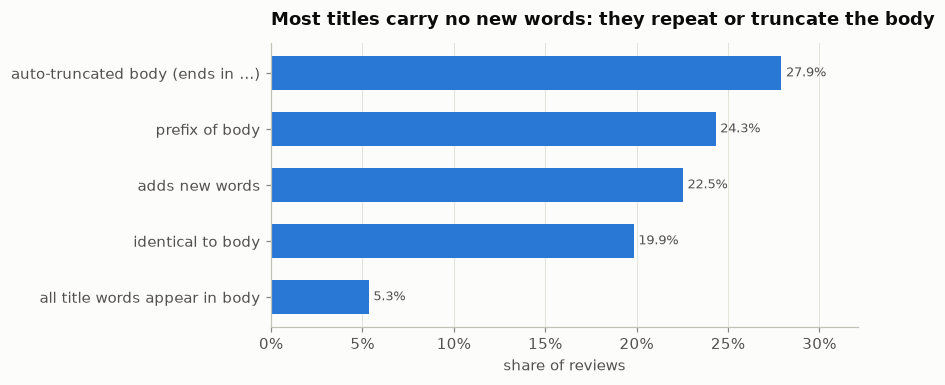

title vs body
auto-truncated body (ends in …)    2793
prefix of body                     2433
adds new words                     2254
identical to body                  1985
all title words appear in body      535


In [6]:
t = title.str.strip()
b = body.str.strip()
t_stem = t.str.rstrip("…").str.rstrip(". ").str.casefold()
b_cf = b.str.casefold()


def relation(ti, bo, ti_stem):
    if ti.casefold() == bo.casefold():
        return "identical to body"
    if ti.endswith("…") and ti_stem and bo.casefold().startswith(ti_stem):
        return "auto-truncated body (ends in …)"
    if ti_stem and bo.casefold().startswith(ti_stem):
        return "prefix of body"
    if set(TOKEN_RE.findall(ti.casefold())) <= set(TOKEN_RE.findall(bo.casefold())):
        return "all title words appear in body"
    return "adds new words"


rel = pd.Series([relation(a, c, s) for a, c, s in zip(t, b, t_stem)], name="title vs body")
rel_counts = rel.value_counts()
hbar(rel_counts / len(rel), "Most titles carry no new words: they repeat or truncate the body",
     xlabel="share of reviews", pct=True)
print(rel_counts.to_string())

In [7]:
# Auto-truncated titles: Trustpilot fills a missing title with the start of the body plus '…'.
ex = pd.DataFrame({"title": t, "body": b, "relation": rel})
ex[ex["relation"] == "auto-truncated body (ends in …)"].sample(5, random_state=3)

,title,body,relation
4134,Det är lite märkligt hur företag som…,Det är lite märkligt hur företag som hos andra recensionstjänster har mer eller mindre genomgående negativa recensioner lyckas ha toppbe...,auto-truncated body (ends in …)
3260,Wont leave me alone despite trying to…,Wont leave me alone despite trying to unsubscribe,auto-truncated body (ends in …)
3239,Thank you Trustpilot for giving us the…,"Thank you Trustpilot for giving us the consumer an option of expressing ourselves through your website, it can be very frustrating when ...",auto-truncated body (ends in …)
3858,They delete/censor anything that doesnt…,They delete/censor anything that doesnt suit them they are a corrupt and puppet company who pick and choose which business to harm or sa...,auto-truncated body (ends in …)
6137,Je ne trouve pas mon avis en ligne…,Je ne trouve pas mon avis en ligne malgré la validation de l’avis et le mail de confirmation...,auto-truncated body (ends in …)


In [8]:
# Titles ending in … that do NOT match the body start: the text changed (case, typo, leading words).
odd = ex[t.str.endswith("…") & (ex["relation"] != "auto-truncated body (ends in …)")]
print(f"{len(odd)} titles end with … but are not an exact body prefix")
odd.head(6)

93 titles end with … but are not an exact body prefix


,title,body,relation
31,el cual…,Perdon la plataforma es genial es la unica manera que me comunique mistertecno dice que me contacta conmigo y es todo mentira,adds new words
218,Trsutpilot is an excellent platform for…,"Trustpilot is an excellent platform for our customers to review our business in, the only down fall is the premium plans are expensive f...",adds new words
270,excellent site pour comparer et ainsi…,Truspilot : excellent site pour comparer et ainsi pouvoir se protéger des site d'arnaque en ligne,all title words appear in body
436,I would prefer not to…,Won’t accept my email address or password. Have to register with Google or Facebook. Wastes my time,adds new words
440,Prima eindelijk geen verplichting om…,Prima eindelijk eens geen verplichting om een google account te moeten maken. Geen google voor mij.,all title words appear in body
482,Trustpilot es un un canal de opinión…,Trustpilot es un n canal de opinión donde las personas podemos expresar nuestras quejas a empresas y sirve para orientar a otras person...,all title words appear in body


**Findings**
- **Most titles add no new words.** About 20% are identical to the body (case-insensitive). About 28% are auto-generated truncations of the body ending in `…`. Another 24% are a prefix of the body, and 5% contain only words that are already in it. **Only about 23% of titles add new words.**
- **A few "…" titles don't exactly match the body start.** The reviewer edited the body afterwards, or the body has a typo or a different first word.
- **Titles in the `…` group end mid-word or mid-phrase** (`…platform for…`). Those cut-off fragments would become fake keywords.

**Implication:** decide on one text field per review. Two options:
- **(a)** Build keywords from the **body only**, and add the title only when it brings new words.
- **(b)** Concatenate the two fields and **deduplicate keyword edges per review** (a review links to a keyword once, possibly with a count).

Either way, drop the trailing `…` fragment of auto-truncated titles. *(Both approaches; an LLM reading "title + body" will also over-weight repeated text.)*

## 4. Language labels

Stopword lists, stemmers, lemmatisers and any translation step all depend on `language`. A wrong label means the wrong stemmer, which means inconsistent nodes. Here each label is checked against an independent detector ([lingua](https://github.com/pemistahl/lingua-py)).

In [9]:
detector = LanguageDetectorBuilder.from_all_languages().with_preloaded_language_models().build()


def detect(texts):
    out = detector.detect_languages_in_parallel_of(list(texts))
    return pd.Series([r.iso_code_639_1.name.lower() if r else "none" for r in out], index=texts.index)


full = (t + ". " + b).str.strip(". ")
n_words = full.str.split().str.len()
detected = detect(full).replace({"nb": "no", "nn": "no"})
mismatch = detected != lang
print(f"Label ≠ detected language: {mismatch.sum():,} reviews ({mismatch.mean():.1%})")

length_bin = pd.cut(n_words, [0, 3, 6, 12, 30, 10_000], labels=["1-3", "4-6", "7-12", "13-30", "31+"])
by_len = mismatch.groupby(length_bin, observed=True).agg(["mean", "size"])
by_len

Label ≠ detected language: 443 reviews (4.4%)


,mean,size
1-3,0.360248,161
4-6,0.163490,1364
7-12,0.062083,1949
13-30,0.009602,3541
31+,0.001006,2981


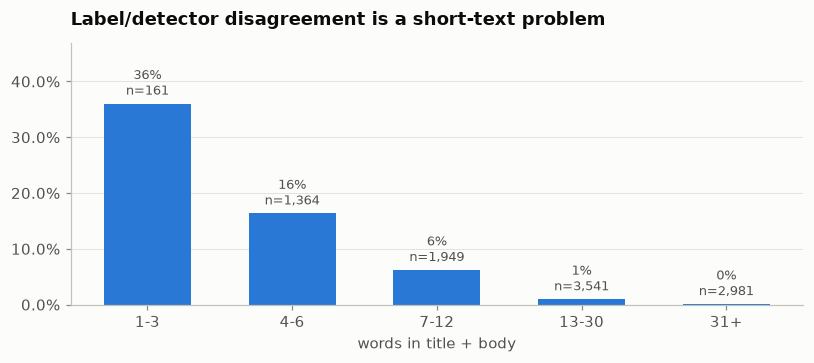

In [10]:
fig, ax = plt.subplots(figsize=(7.5, 3.4))
bars = ax.bar(by_len.index.astype(str), by_len["mean"], color=BLUE, width=0.6)
ax.bar_label(bars, labels=[f"{m:.0%}\nn={n:,}" for m, n in zip(by_len["mean"], by_len["size"])],
             padding=3, fontsize=8.5, color=INK_2)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_ylim(0, by_len["mean"].max() * 1.3)
ax.grid(axis="x", visible=False)
ax.set_xlabel("words in title + body")
ax.set_title("Label/detector disagreement is a short-text problem")
plt.tight_layout()
plt.show()

In [11]:
# Short texts: the detector, not the label, is usually wrong - and the brand name is part of the problem.
short = mismatch & (n_words <= 6)
pd.DataFrame({"label": lang, "detected": detected, "text": full})[short].sample(10, random_state=1)

,label,detected,text
3312,da,de,Finde ich klasse. Finde ich klasse
3655,en,nl,I likelike trustpilot. I likelike trustpilot
5934,no,da,Det virker fint. Det virker fint
7265,en,pl,Easy Platform Integra. Easy Platform Integra
9300,vi,cs,Hcjdnxnxndnjdccc. Hcjdnxnxndnjd
8733,en,fr,Evaluation Trustpilot. Simple et efficace
3369,und,none,👍👍👍👍👍👍👍👍👍👍👍👍👍👍. 👍👍👍👍👍👍👍👍👍👍👍👍👍👍
8319,en,fr,Excellent service..... Excellent service
6792,en,so,Good. Good good good
993,de,none,👍👍👍👍👍👍👍👍👍👍👍👍👍👍👍👍👍👍. 👍👍👍👍👍👍👍👍👍👍👍👍👍👍👍👍👍👍


In [12]:
# Does masking the brand name reduce disagreement? ('Trustpilot' looks Danish/Germanic to a detector.)
brand_re = re.compile(r"(?i)\btr?u?st\s?-?p\w*lo?t\w*|\btp\b")
masked = full.str.replace(brand_re, " ", regex=True).str.strip()
detected_masked = detect(masked).replace({"nb": "no", "nn": "no"})
print(f"Disagreement with brand name kept:   {mismatch.mean():.1%}")
print(f"Disagreement with brand name masked: {(detected_masked != lang).mean():.1%}")

Disagreement with brand name kept:   4.4%
Disagreement with brand name masked: 4.0%


In [13]:
# Long texts (13+ words): disagreement here is usually a real labelling error or a mixed-language review.
long_mm = mismatch & (n_words >= 13)
print(f"{long_mm.sum()} long reviews where label ≠ detected")
print(pd.crosstab(lang[long_mm], detected[long_mm]).stack().loc[lambda s: s > 0].sort_values(ascending=False).head(10).to_string())
pd.DataFrame({"label": lang, "detected": detected, "text": full.str[:150]})[long_mm].sample(8, random_state=0)

37 long reviews where label ≠ detected
language  col_0
en        da       11
          nl        3
no        da        3
da        no        2
nl        af        2
ru        en        2
ca        es        1
co        it        1
fr        da        1
en        de        1


,label,detected,text
6187,da,no,Det er rart at kunne se anmeldelser på trust pilot. Det er rart at kunne se anmeldelser på trust pilot
4677,fr,da,"Je ne suis pas un robot. Je ne suis pas un robot, et je ne connais pas Trustpilot?"
3678,no,da,"Egentlig et godt projekt. Egentlig et godt projekt, men ærgerligt, at ""robotten"" konstant sorterer reelle anmeldelser fra"
2912,en,da,why did i get this. why did i get this. i do not want to use trustpilot
8176,en,es,You are de Best People en whit gran…. You are de Best People en whit gran atención
7424,en,da,"Trustpilot, gets (5) Five Stars. Trustpilot, gets 5 Stars. As far as I can tell, ""Excellent""...\nPBO"
3631,en,da,⭐⭐⭐⭐⭐ Solid Five Stars. ⭐⭐⭐⭐⭐ Solid Five Stars - Trust Your Pilot. Trust Pilot. TrustPilot.com
3416,en,da,TrustPilot. One place I go to check for a scam of a website


In [14]:
# Mixed-language reviews: title and body each long enough to detect, but in different languages.
ok = (t.str.split().str.len() >= 4) & (b.str.split().str.len() >= 4) & (rel == "adds new words")
dt, db = detect(t[ok]), detect(b[ok])
mixed = dt != db
print(f"Of {ok.sum():,} reviews with an independent 4+ word title and body, {mixed.sum()} have title and body in different languages")
pd.DataFrame({"label": lang[ok], "title_lang": dt, "body_lang": db, "title": t[ok], "body": b[ok].str[:100]})[mixed].head(8)

Of 1,142 reviews with an independent 4+ word title and body, 104 have title and body in different languages


,label,title_lang,body_lang,title,body
150,en,da,en,Trustpilot is for the bots and shills.,This company’s review policies benefit negative reviews which allow for inorganic retains to occur a
199,en,so,en,So far so good...,Imagine the potential...when reviews offer extra benefit for those who write exceptional win-win opi
218,en,de,en,Trsutpilot is an excellent platform for…,"Trustpilot is an excellent platform for our customers to review our business in, the only down fall"
238,da,nb,da,Mega dårlig side de tro ikke på det man skriver,Rigtig dårlig side de tro ikke på det man skrive så vil slet ikke anbefale trustpilot til nogen
291,en,da,en,"Forgive the oxymoron, but I trust Trustpilot...","While consumer reviews are by nature subjective, any company that can maintain a rating above four s"
475,de,da,de,Trustpilot ? Find ich GUT!,"Trustpilot als informative Anlaufstelle für unbekanntes, aber durchaus interessantes Neuland hat sic"
497,en,da,en,Bookmark Trustpilot as your go to source of information,I value Trustpilot as my chief source of trustworthy information. Their platform has saved me many
560,fr,da,fr,Merci à Trustpilot d'exister.,"Pour avoir consulté et tiré bénéfice des avis laissés via Trustpilot,\nje n'ignorais pas son existenc"


In [15]:
# Script check: non-Latin text under a Latin-script label (or the reverse).
def script(s):
    names = [unicodedata.name(ch, "").split(" ")[0] for ch in s if ch.isalpha()]
    return Counter(names).most_common(1)[0][0] if names else "NONE"


scr = full.map(script)
pd.crosstab(lang.where(lang.isin(lang.value_counts().head(12).index), "other"), scr)

col_0,ARABIC,CYRILLIC,HIRAGANA,LATIN,NONE,THAI
language,,,,,,
da,0,0,0,729,2,0
de,0,0,0,1541,3,0
en,1,0,0,4342,4,0
es,0,0,0,365,0,0
fr,0,0,0,1179,0,0
it,0,0,0,669,0,0
nl,0,0,0,556,0,0
no,0,0,0,68,0,0
other,28,1,2,104,7,4


**Findings**
- **The detector disagrees with the label on 4.4% of reviews, and almost all of that is short text.** It disagrees on 36% of reviews with 1–3 words, but only 1% of reviews with 13–30 words and 0.1% with 31+ words. Short phrases like "Excellent service" or "Good. Good good good" are valid in several languages, or none, so the *detector* is usually the unreliable part.
- **Short texts still hide some genuine mislabels**, though: "Finde ich klasse" is labelled `da` but is German. These can't be told apart from detector errors automatically.
- **The brand name confuses detection.** "Trustpilot" pulls texts towards Danish. Masking it lowers disagreement only a little (4.4% → 4.0%).
- **The 37 disagreements in long texts are mostly detector errors too**: brand-heavy English texts detected as `da`, and Danish/Norwegian swaps (a near-identical pair). Clear mislabels are rare.
- **Title-vs-body language "mismatches" (104 of 1,142)** turn out to be mostly the short title being misdetected, not truly mixed-language reviews.
- **Writing scripts match the labels** (Latin, Cyrillic, Arabic, Thai…) apart from a couple of exceptions, so there are no gross encoding mix-ups.

**Implication:**
- **Keep the provided label as the default.** It is more reliable than re-detection on this data.
- **Optionally re-detect long texts** (with the brand name masked) as a sanity flag, but don't overwrite labels automatically.
- **Group `no`/`nb` (and probably `da`)** when choosing stopwords and stemmers.
- **Route `und` and languages without NLP resources** to a "no stemming" fallback.

Language-specific stemming or stopwords are a classic-NLP concern. An LLM can handle each review's own language without that, but its outputs then need a shared label vocabulary (section 13).

## 5. Brand-name variants ("Trustpilot")

The subject of almost every review is written in dozens of ways. Each spelling becomes its own keyword node, and the spaced form **"trust pilot" leaks into the generic keyword "trust"**.

88 distinct surface forms for one entity


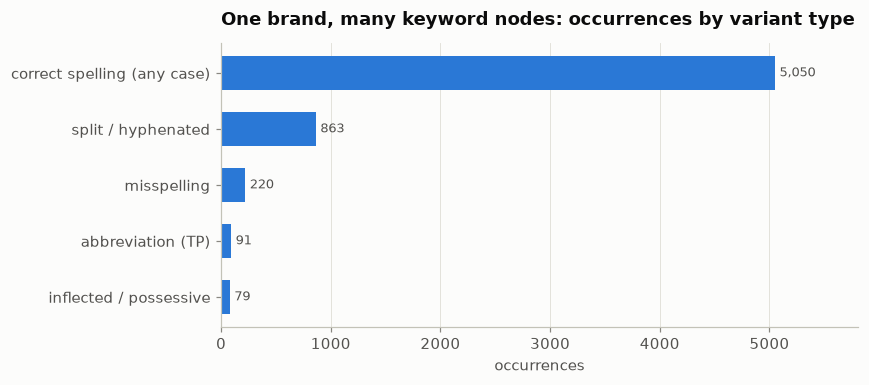

,top variants
type,
abbreviation (TP),"TP (87), tp (4)"
correct spelling (any case),"Trustpilot (3732), trustpilot (972), TrustPilot (180), TRUSTPILOT (161), trustPilot (2), TRUSTpilot (1), TrustpiloT (1), TrustPIlot (1)"
inflected / possessive,"Trustpilots (36), trustpilots (15), Trust pilots (6), trust pilote (3), Trust pilote (3), Trustpilote (3), Trustpiloten (2), TrustPilots..."
misspelling,"Truspilot (98), truspilot (31), TRUSPILOT (11), Thrustpilot (5), Trustpliot (4), Testpilot (4), Trustpillot (3), Trustpiolet (3)"
split / hyphenated,"trust pilot (352), Trust Pilot (245), Trust pilot (243), TRUST PILOT (14), TRUST pilot (4), Trust-Pilot (2), TRust Pilot (1), Trust-pilo..."


In [16]:
brand_any = re.compile(r"(?i)\b(?:tr?u?s?t?\s?-?p\w{0,3}l\w{0,2}o?t\w*|t\w{0,3}st\s?-?pil\w*|tp)\b")
variants = Counter(m.group(0) for s in both for m in brand_any.finditer(s))
# keep things that look like the brand (filters out e.g. 'trust plot' false hits)
variants = Counter({k: v for k, v in variants.items() if re.search(r"(?i)p\w*l\w*o?t|^tp$", k)})


def variant_type(v):
    k = v.casefold()
    if k in {"tp"}:
        return "abbreviation (TP)"
    if re.search(r"\.(com|co|de|fr|dk)", k):
        return "domain"
    if re.fullmatch(r"trust\s?-?pilot", k):
        if " " in k or "-" in k:
            return "split / hyphenated"
        return "correct spelling (any case)"
    if re.fullmatch(r"trust\s?-?pilot(?:s|'s|’s|s'|e|en|s’)", k):
        return "inflected / possessive"
    return "misspelling"


vt = pd.DataFrame(variants.items(), columns=["variant", "n"]).sort_values("n", ascending=False)
vt["type"] = vt["variant"].map(variant_type)
print(f"{len(vt)} distinct surface forms for one entity")
hbar(vt.groupby("type")["n"].sum().sort_values(ascending=False),
     "One brand, many keyword nodes: occurrences by variant type", xlabel="occurrences")
vt.groupby("type").apply(lambda g: ", ".join(f"{v} ({n})" for v, n in g.head(8)[["variant", "n"]].values),
                         include_groups=False).to_frame("top variants")

In [17]:
domains = Counter(m.group(0).lower() for s in both for m in re.finditer(r"(?i)\b[\w-]+\.(?:com|co\.uk|de|fr|dk|net|org|it|es|nl)\b", s))
print("Domains mentioned:", domains.most_common(10))

# How much of the generic keyword 'trust' is really the brand split in two?
trust_tokens = sum(len(re.findall(r"(?i)\btrust\b", s)) for s in both)
trust_in_brand = sum(len(re.findall(r"(?i)\btrust[\s-]+pil+o?t", s)) for s in both)
print(f"Standalone token 'trust': {trust_tokens:,} occurrences, of which {trust_in_brand:,} "
      f"({trust_in_brand / trust_tokens:.0%}) are the first half of 'trust pilot'")

Domains mentioned: [('trustpilot.com', 46), ('conte.it', 9), ('thedesignszone.com', 6), ('opodo.de', 5), ('wish.com', 5), ('homeaway.co.uk', 5), ('bittrust.net', 4), ('trustpilot.net', 4), ('spilnu.dk', 3), ('lightinthebox.com', 2)]
Standalone token 'trust': 1,382 occurrences, of which 883 (64%) are the first half of 'trust pilot'


**Findings**
- **88 distinct surface forms of one brand.** These include casing (`TrustPilot`, `TRUSTPILOT`), splitting (`trust pilot`, `Trust-Pilot`), inflection (`Trustpilots`, `Trustpilot's`), misspellings (`Truspilot` is common, with 100+ uses, plus `Trustpliot`, `turstpilot`, `yrustpilot`…), the abbreviation `TP`, and the domain `trustpilot.com`.
- **64% of all standalone `trust` tokens are really the brand**, written as "trust pilot". Without fixing this, the keyword *trust* (a real theme, see notebook 01) is mostly brand mentions, and a meaningless `pilot` node appears (about 5% of reviews, section 12).

**Implication:** canonicalise the brand **before tokenising**, using a fuzzy brand regex for spacing, hyphens, inflection, typos, the domain and `TP` (when it stands alone). Then either map every variant to one token such as `trustpilot`, or drop it as a domain stopword (section 12). *(Both approaches; an LLM will also emit inconsistent entity names unless its output is normalised.)*

## 6. Casing

In [18]:
tokens_all = [tok for s in body for tok in TOKEN_RE.findall(s)]
case_forms = defaultdict(Counter)
for tok in tokens_all:
    case_forms[tok.casefold()][tok] += 1
n_raw, n_cf = len(set(tokens_all)), len(case_forms)
print(f"Distinct body tokens: {n_raw:,} raw → {n_cf:,} after casefold ({1 - n_cf / n_raw:.0%} fewer)")
multi = sorted(((k, v) for k, v in case_forms.items() if len(v) >= 3), key=lambda kv: -sum(kv[1].values()))
print(f"Words appearing in 3+ case forms: {len(multi)}")
pd.DataFrame([(k, dict(v.most_common(5))) for k, v in multi[:10]], columns=["casefolded", "forms (count)"])

Distinct body tokens: 33,144 raw → 28,399 after casefold (14% fewer)
Words appearing in 3+ case forms: 777


,casefolded,forms (count)
0,to,"{'to': 5000, 'To': 36, 'TO': 32}"
1,the,"{'the': 3965, 'The': 358, 'THE': 47, 'thE': 1}"
2,trustpilot,"{'Trustpilot': 2745, 'trustpilot': 737, 'TrustPilot': 135, 'TRUSTPILOT': 120, 'TrustpiloT': 1}"
3,and,"{'and': 3579, 'And': 93, 'AND': 28}"
4,of,"{'of': 2172, 'OF': 14, 'Of': 8}"
5,is,"{'is': 2122, 'Is': 33, 'IS': 23}"
6,for,"{'for': 2054, 'For': 41, 'FOR': 20}"
7,de,"{'de': 1974, 'De': 72, 'DE': 17}"
8,reviews,"{'reviews': 1913, 'Reviews': 44, 'REVIEWS': 17}"
9,you,"{'you': 1691, 'You': 242, 'YOU': 34}"


In [19]:
def caps_ratio(s):
    w = re.findall(r"\b[^\W\d_]{3,}\b", s)
    return sum(x.isupper() for x in w) / len(w) if len(w) >= 3 else np.nan


shout = body.map(caps_ratio) > 0.6
print(f"Bodies written mostly in CAPITALS: {shout.sum()} ({shout.mean():.1%});  1★ share among them: {(stars[shout] == 1).mean():.0%} vs {(stars == 1).mean():.0%} overall")
# Edge case: 'İ'.casefold() produces 'i' + COMBINING DOT ABOVE - a token that looks right but never matches.
weird = [k for k in case_forms if "\u0307" in k]
print("Casefolded tokens containing U+0307 COMBINING DOT ABOVE:", weird)

Bodies written mostly in CAPITALS: 89 (0.9%);  1★ share among them: 26% vs 16% overall
Casefolded tokens containing U+0307 COMBINING DOT ABOVE: ['i̇st', 'i̇ts']


**Findings**
- **Casefolding removes about 14% of the distinct body tokens.** 777 words appear in three or more case forms, and the brand alone has seven.
- **About 1% of bodies (89) are written mostly in capitals**, and these are disproportionately 1★ (26% vs 16% overall). The capitals are a *signal* (shouting) and should not create separate nodes.
- **There is one Unicode trap.** The Turkish capital `İ` casefolds to `i` + combining dot (`i̇st`, `i̇ts`), which looks like `ist`/`its` but never matches it.

**Implication:** `casefold()` all keyword candidates, then strip U+0307 after casefolding. If shouting is useful, keep it as a *review attribute* (`caps_ratio`), not as a token feature. German capitalises nouns, but folding is still right for keyword nodes. If proper-noun recognition is needed, run NER **before** lowercasing. *(Critical for classic NLP; for an LLM, normalise the output labels.)*

## 7. Punctuation and typography

In [20]:
punct = pd.Series({
    "typographic apostrophe ’ (U+2019)": both.str.contains("’").sum(),
    "straight apostrophe '": both.str.contains("'").sum(),
    "typographic double quotes “ ” „ « »": both.str.contains("[“”„«»]").sum(),
    "ellipsis character …": both.str.contains("…").sum(),
    "three+ dots ...": both.str.contains(r"\.{3,}").sum(),
    "repeated !! / ??": both.str.contains(r"[!?]{2,}").sum(),
    "letter elongation (sooo, goood)": both.str.contains(r"([^\W\d_])\1{2,}").sum(),
    "dashes – — (not hyphen)": both.str.contains("[–—]").sum(),
}, name="texts")
punct.to_frame()

,texts
typographic apostrophe ’ (U+2019),532
straight apostrophe ',1783
typographic double quotes “ ” „ « »,105
ellipsis character …,3007
three+ dots ...,627
repeated !! / ??,633
"letter elongation (sooo, goood)",83
dashes – — (not hyphen),6


In [21]:
# The same English contraction in three spellings -> three different keyword candidates.
en_body = body[lang == "en"]
contr = Counter(m.group(0).lower() for s in en_body
                for m in re.finditer(r"\b(?:don|can|won|didn|doesn|isn|wasn|i|you|they|it)(?:['’]?)(?:t|m|re|ve|ll|s)\b", s))
families = defaultdict(dict)
for form, n in contr.items():
    families[form.replace("’", "").replace("'", "")][form] = n
pd.DataFrame([(k, v) for k, v in sorted(families.items(), key=lambda kv: -sum(kv[1].values())) if len(v) > 1][:10],
             columns=["contraction", "spellings (count)"])

,contraction,spellings (count)
0,dont,"{'don't': 189, 'don’t': 59, 'dont': 33}"
1,cant,"{'can't': 54, 'cant': 8, 'can’t': 22}"
2,didnt,"{'didn't': 57, 'didn’t': 21, 'didnt': 4}"
3,doesnt,"{'doesn’t': 10, 'doesn't': 40, 'doesnt': 4}"
4,wont,"{'wont': 5, 'won't': 29, 'won’t': 8}"
5,youre,"{'you're': 22, 'you’re': 13}"
6,wasnt,"{'wasn’t': 10, 'wasn't': 17, 'wasnt': 1}"
7,isnt,"{'isn’t': 6, 'isnt': 3, 'isn't': 14}"
8,youve,"{'you've': 14, 'you’ve': 4}"
9,theyre,"{'they're': 10, 'theyre': 1, 'they’re': 3}"


In [22]:
# Hyphenation / compounding: same word written hyphenated, spaced or closed (English bodies).
en_lower = en_body.str.lower()
uni = Counter(w for s in en_lower for w in re.findall(r"[a-z]+(?:-[a-z]+)*", s))
bi = Counter(" ".join(p) for s in en_lower for p in zip(*(lambda w: (w, w[1:]))(re.findall(r"[a-z]+", s))))
rows = [(w, n, bi.get(w.replace("-", " "), 0), uni.get(w.replace("-", ""), 0)) for w, n in uni.items() if "-" in w]
hy = pd.DataFrame(rows, columns=["hyphenated", "n_hyphenated", "n_spaced", "n_closed"])
hy = hy[(hy["n_spaced"] + hy["n_closed"]) > 0]
hy.assign(total=hy[["n_hyphenated", "n_spaced", "n_closed"]].sum(axis=1)).sort_values("total", ascending=False).head(12)

,hyphenated,n_hyphenated,n_spaced,n_closed,total
111,trust-pilot,1,563,2006,2570
59,thank-you,2,305,12,319
30,web-site,1,12,259,272
8,e-mail,9,10,245,264
47,on-line,3,24,145,172
1,e-mails,6,7,123,136
16,go-to,3,56,0,59
7,one-star,9,32,0,41
26,check-out,1,26,6,33
17,no-one,5,25,3,33


In [23]:
elong = Counter(m.group(0) for s in both for m in re.finditer(r"\b\w*([^\W\d_])\1{2,}\w*\b", s))
print("Elongated words:", ", ".join(f"{w} ({n})" for w, n in elong.most_common(20)))

Elongated words: xxx (4), Okkkk (2), ittttttt (2), Goood (2), Merciiiiiiiiii (2), AAA (2), Guhhhuuh (2), tanxxx (2), Soooo (2), gooood (2), TOLLL (2), Tjaaaa (2), miticiiii (2), Zeeer (2), booooooooooooooooooooooood (2), Siiiiii (2), goood (2), جدااا (2), xxxx (2), Gooood (2)


**Findings**
- **Apostrophes come in three or four spellings**: `don't` / `don’t` / `dont` (plus `don´t` using the acute accent, section 2), and the same for `can't`, `didn't`, `you're` and others. That is three keyword candidates per contraction, and the bare forms (`dont`, `im`, `ill`) can collide with other words (`ill`).
- **Ellipses are both the `…` character (about 3,000 texts, mostly auto-truncated titles) and `...` dot runs (about 600 texts).**
- **Compound words are written three ways**: `email`/`e-mail`/`e mail`, `website`/`web-site`/`web site`, `online`/`on-line`, `go-to`/`go to`, `one-star`/`one star`, `thank you`/`thankyou`. The hyphenated form is rare, but the spaced and closed forms often coexist. The biggest case is the brand itself (`trustpilot` 2,006 / `trust pilot` 563).
- **Elongations** (`soooo`, `goood`, `Merciiiiii`, `booooooood`) and repeated `!!!` are emphasis, not new words.

**Implication:**
- Map typographic quotes and apostrophes to ASCII.
- Expand or unify contractions, or treat them as stopwords (most are anyway).
- Unify `...`/`…` and drop them from tokens.
- Squeeze letter runs of 3+ down to 2, then spell-check against a lexicon (section 10).
- Apply a small compound-normalisation map (`e-mail`→`email`, `web site`→`website`…).

The emphasis signals (`!!!`, elongations) can be kept as review attributes. *(Classic NLP; an LLM is robust to these, but its keyword output needs the same map.)*

## 8. Non-word tokens: emoji, URLs, numbers

In [24]:
emo = both.map(lambda s: [e["emoji"] for e in emoji.emoji_list(s)])
emo_counts = Counter(e for l in emo for e in l)
print(f"Texts with emoji: {(emo.str.len() > 0).sum():,};  distinct emoji: {len(emo_counts)}")
print("Top emoji:", " ".join(f"{e}×{n}" for e, n in emo_counts.most_common(15)))

body_emo_only = body.map(lambda s: bool(s.strip()) and not TOKEN_RE.search(emoji.replace_emoji(s, "")) and emoji.emoji_count(s) > 0)
print(f"Bodies that are emoji only: {body_emo_only.sum()}")

Texts with emoji: 710;  distinct emoji: 150
Top emoji: 👍×626 ⭐×101 😊×94 👌×65 ❤️×60 👍🏻×42 ✌🏾×39 😉×34 👏×32 😘×28 😀×27 💯×27 🙂×24 😁×22 👍🏼×20


Bodies that are emoji only: 11


In [25]:
patterns = {
    "URL / domain": r"https?://\S+|www\.\S+|\b[\w-]+\.(?:com|co\.uk|de|fr|dk|net|org|io|it|es|nl)\b",
    "email address": r"[\w.+-]+@[\w-]+\.[\w.]+",
    "@mention": r"(?<!\w)@\w{2,}",
    "#hashtag / #number": r"(?<!\w)#\w+",
    "phone / long digit ID (8+ digits)": r"\+?\d[\d \-]{7,}\d",
    "date": r"\b\d{1,2}[/.\-]\d{1,2}[/.\-]\d{2,4}\b",
    "money amount": r"[£$€]\s?\d|\d\s?(?:€|eur|usd|dkk|sek|nok|kr)\b",
    "other standalone number": r"\b\d+\b",
}
rows = []
for name, p in patterns.items():
    m = both.str.contains(p, case=False, regex=True)
    rows.append((name, m.sum(), both[m].str.extract("(" + p + ")", flags=re.I)[0].head(4).tolist()))
pd.DataFrame(rows, columns=["pattern", "texts", "examples"])

,pattern,texts,examples
0,URL / domain,163,"[Trustpilot.com, trustpilot.com, 5pounds.com, Trustpilot.com]"
1,email address,0,[]
2,@mention,4,"[@whatever, @Trustpilot, @trustpilot, @cucineLube]"
3,#hashtag / #number,21,"[#trustjacked, #trustjacked, #10056894, #UPDATE]"
4,phone / long digit ID (8+ digits),20,"[0941290739, 1123123123123123, 32-0400058, 11-08-2021]"
5,date,41,"[30/08/2021, 2/12-2021, 23.10.21, 17.08.2021]"
6,money amount,57,"[$1, 0kr, $4, $1]"
7,other standalone number,1097,"[1, 1, 100, 5]"


**Findings**
- **710 texts (titles or bodies) contain emoji, with 150 distinct emoji.** 👍 dominates, and many of those were HTML-escaped (section 2). Skin-tone variants (👍🏻 👍🏼 ✌🏾) are separate code sequences of the same emoji. The rest are mostly positive (⭐ 😊 👌 ❤️). There are 11 **emoji-only bodies**.
- **URLs and domains (163 texts)** are mainly `trustpilot.com` (brand, section 5) plus third-party shops (`conte.it`, `opodo.de`, `wish.com`…). **There are no email addresses.**
- **The digit strings are noise for a keyword graph**: phone numbers and reference IDs (about 20), dates in several formats (`30/08/2021`, `23.10.21`, `2/12-2021`; about 40), money amounts (about 60), and about 1,100 texts with bare numbers (often star counts: "1 star", "5 stars").
- **Hashtags and @mentions are rare.** Some `#…` are actually reference numbers.

**Implication:**
- **Emoji:** either drop them, or turn them into text aliases (`emoji.demojize` → `thumbs_up`) and keep them as a separate *sentiment* signal, not mixed into keyword nodes.
- **URLs, phone numbers/IDs, dates and amounts:** mask them with placeholders (`<URL>`, `<NUM>`, `<DATE>`, `<MONEY>`) or drop them. They should never become keyword nodes. Phone numbers and IDs are also a privacy concern.
- **Star mentions:** keep "N star(s)" as one normalised phrase if a rating-mention feature is wanted.

*(Both approaches; this masking also stops an LLM from echoing IDs into topics.)*

## 9. Diacritics: what is safe to fold

People sometimes skip accents (`tres` for `très`, `nao` for `não`). Stripping all accents looks like the obvious fix, but this section checks what it would merge.

In [26]:
def strip_accents(s):
    return "".join(c for c in unicodedata.normalize("NFD", s) if unicodedata.category(c) != "Mn")


rows = []
for lg in ["fr", "de", "es", "it", "pt", "da", "sv", "nl"]:
    freq = Counter(w.casefold() for s in body[lang == lg] for w in TOKEN_RE.findall(s))
    groups = defaultdict(list)
    for w, n in freq.items():
        groups[strip_accents(w)].append((w, n))
    coll = sorted((v for v in groups.values() if len(v) > 1), key=lambda v: -sum(n for _, n in v))
    rows.append((lg, len(coll), "; ".join("/".join(f"{w}({n})" for w, n in sorted(v, key=lambda x: -x[1])) for v in coll[:6])))
pd.DataFrame(rows, columns=["language", "accent-folding collisions", "top collisions"])

,language,accent-folding collisions,top collisions
0,fr,169,à(427)/a(184); des(339)/dès(4)/dés(1); très(296)/tres(36)/trés(2); site(323)/sité(1); la(275)/là(13); sur(257)/sûr(3)
1,de,27,ist(432)/i̇st(1); super(150)/süper(1); schon(72)/schön(22); wurde(65)/würde(25); andere(54)/ändere(1); hatte(29)/hätte(19)
2,es,52,que(333)/qué(11); opinión(38)/opinion(11); mi(48)/mí(1); esta(28)/está(18)/ésta(1); como(38)/cómo(3); si(24)/sí(3)
3,it,25,e(474)/è(203)/é(1); da(105)/dà(2)/dá(1); si(94)/sì(1); se(90)/sé(1); più(68)/piu(3); perché(47)/perchè(15)/perche(2)
4,pt,19,e(66)/é(21); a(46)/à(3); as(21)/às(1); não(20)/nao(2); ótimo(8)/otimo(2); fácil(5)/facil(1)
5,da,7,en(460)/én(1); et(198)/ét(1); den(136)/dén(1); får(43)/far(1); går(20)/gär(1); a(12)/à(1)
6,sv,9,är(105)/år(4); har(49)/här(12); var(4)/vår(2); a(4)/å(2); val(2)/väl(2); värna(2)/varna(1)
7,nl,3,een(385)/één(3); zeer(43)/zéér(2); verifieren(1)/verifiëren(1)


**Findings.** Folding accents merges two very different kinds of pair:

| Kind | Examples | Should they merge? |
|---|---|---|
| **Missing-accent typos** | `très`/`tres`, `opinión`/`opinion`, `più`/`piu`, `perché`/`perchè`/`perche`, `não`/`nao`, `ótimo`/`otimo` | ✅ yes |
| **Different words** | FR `à`/`a`, `sûr`/`sur`; DE `schön`/`schon`, `würde`/`wurde`, `hätte`/`hatte`; SV `här`/`har`, `år`/`är`; IT `è`/`e`; ES `está`/`esta` | ❌ no, the meaning changes |

In German and Swedish especially, the colliding pairs are mostly *distinct words*.

**Implication:** **do not strip accents across the board.** Use per-language handling instead: keep the accents, and fix missing-accent typos either with a lexicon-based correction (a folded form maps to the accented dictionary word only when it is unambiguous) or by lemmatising with a proper lemmatiser. Many of the colliding pairs are stopwords, so stopword removal hides part of the problem but not all of it. *(Classic NLP; LLMs handle this natively.)*

## 10. Spelling errors

A simple test: rare words (≤3 uses) that are one edit away from a frequent word (≥15 uses), in English bodies.

In [27]:
letters = "abcdefghijklmnopqrstuvwxyz'"


def edits1(w):
    splits = [(w[:i], w[i:]) for i in range(len(w) + 1)]
    return {a + b[1:] for a, b in splits if b} | {a + b[1] + b[0] + b[2:] for a, b in splits if len(b) > 1} \
        | {a + c + b[1:] for a, b in splits if b for c in letters} | {a + c + b for a, b in splits for c in letters}


en_freq = Counter(w.casefold().replace("’", "'") for s in en_body for w in TOKEN_RE.findall(s))
frequent = {w for w, n in en_freq.items() if n >= 15 and len(w) >= 4}
cands = []
for w, n in en_freq.items():
    if n <= 3 and len(w) >= 5 and w not in frequent:
        hits = [c for c in edits1(w) if c in frequent]
        if hits:
            cands.append((w, n, max(hits, key=en_freq.get)))
typo = pd.DataFrame(cands, columns=["rare word", "n", "nearest frequent word"])
typo["frequent word count"] = typo["nearest frequent word"].map(en_freq)
print(f"{len(typo)} rare English words are 1 edit from a frequent word ({typo['n'].sum()} occurrences)")
pd.concat([typo.sort_values("frequent word count", ascending=False).head(15),
           typo[typo["rare word"].isin(["width", "trusty", "trusts", "serviced", "withe", "reviewo"])]])

549 rare English words are 1 edit from a frequent word (771 occurrences)


,rare word,n,nearest frequent word,frequent word count
517,tristpilot,1,trustpilot,1961
49,trustpliot,2,trustpilot,1961
497,trastpilot,1,trustpilot,1961
495,trustpulot,1,trustpilot,1961
535,trustpiulot,1,trustpilot,1961
533,trustpiliot,1,trustpilot,1961
379,tustpilot,2,trustpilot,1961
403,trustpoilot,1,trustpilot,1961
164,trustpilet,1,trustpilot,1961
163,trustpillot,1,trustpilot,1961


**Findings**
- **549 candidate misspellings (771 occurrences).** The frequent targets are domain words, such as `reveiw`/`rewiew`/`reviwes` for *review*, `compny`/`compony` for *company*, `servive` for *service*, and more than a dozen misspellings of *Trustpilot*.
- **But edit distance also flags real words**: `width`→with, `trusts`→trust, `serviced`→service, `trusty`→trust. These are inflections or different words, not typos.

**Implication:** **avoid generic auto-correction.** Use **targeted correction against a domain lexicon** (brand, review, company, service, website, account, scam, fake…) with fuzzy matching. Leave the long tail alone, because rare words seldom become meaningful graph nodes, so a frequency threshold on keyword nodes does the rest. *(Classic NLP; an LLM reads through typos.)*

## 11. Morphology: inflection, stemming and compounds

`review`, `reviews`, `reviewed`, `reviewing` and `review's` are one concept. Here, Snowball stemming per language is used to measure how much inflection splits the vocabulary, and where stemming goes too far.

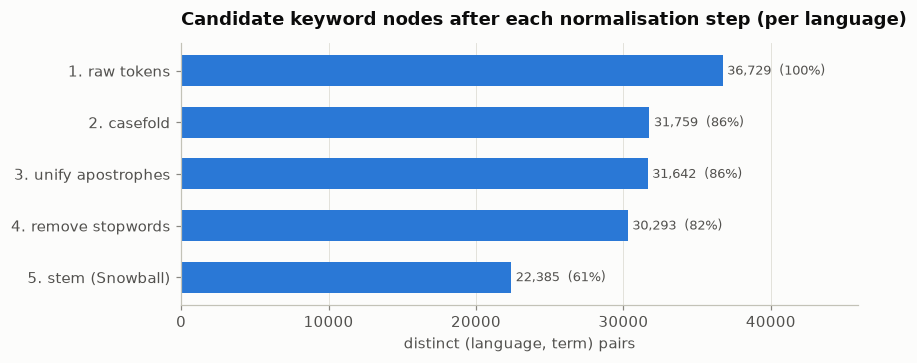

In [28]:
funnel = defaultdict(set)
for lg, s in body.groupby(lang):
    name = NLTK_LANG.get(lg)
    sw = set(stopwords.words(name)) if name else set()
    stem = SnowballStemmer(name).stem if name in SnowballStemmer.languages else (lambda w: w)
    for text in s:
        toks = TOKEN_RE.findall(text)
        for w in toks:
            funnel["1. raw tokens"].add((lg, w))
            c = w.casefold()
            funnel["2. casefold"].add((lg, c))
            c = c.replace("’", "'")
            funnel["3. unify apostrophes"].add((lg, c))
            if c in sw:
                continue
            funnel["4. remove stopwords"].add((lg, c))
            funnel["5. stem (Snowball)"].add((lg, stem(c)))
funnel_counts = pd.Series({k: len(v) for k, v in sorted(funnel.items())})

fig, ax = plt.subplots(figsize=(8, 3.4))
bars = ax.barh(funnel_counts.index[::-1], funnel_counts.values[::-1], color=BLUE, height=0.6)
ax.bar_label(bars, labels=[f"{v:,}  ({v / funnel_counts.iloc[0]:.0%})" for v in funnel_counts.values[::-1]],
             padding=3, fontsize=8.5, color=INK_2)
ax.set_xlim(0, funnel_counts.max() * 1.25)
ax.grid(axis="y", visible=False)
ax.set_title("Candidate keyword nodes after each normalisation step (per language)")
ax.set_xlabel("distinct (language, term) pairs")
plt.tight_layout()
plt.show()

In [29]:
# Largest inflection families in English (one stem, many surface forms).
st_en = SnowballStemmer("english")
fam = defaultdict(Counter)
for w, n in en_freq.items():
    fam[st_en.stem(w)][w] += n
fam_tbl = pd.DataFrame([(s, len(f), sum(f.values()), ", ".join(w for w, _ in f.most_common(8)))
                        for s, f in fam.items()], columns=["stem", "forms", "occurrences", "surface forms"])
fam_tbl.sort_values(["forms", "occurrences"], ascending=False).head(10)

,stem,forms,occurrences,surface forms
28,review,9,3777,"reviews, review, reviewing, reviewed, reviewers, reviewer, review's, reviewes"
180,manag,9,62,"manager, management, manage, managed, managers, managing, manager's, manages"
1207,oper,8,26,"operate, operation, operating, operated, operates, operations, operators, operative"
182,inform,7,225,"information, informed, informative, inform, informing, informs, informational"
82,reason,7,106,"reason, reasons, reasonable, reasoning, reasoned, reason's, reasonably"
154,integr,7,100,"integrity, integration, integrating, integrate, integrates, integral, integrated"
476,public,7,83,"public, publicly, publication, publications, publics, publicity, publicize"
206,continu,7,64,"continue, continues, continually, continuing, continuous, continued, continual"
959,exist,7,35,"exist, existent, exists, existed, existing, existant, existence"
772,reflect,7,32,"reflect, reflected, reflection, reflects, reflecting, reflective, reflections"


In [30]:
# Over-stemming: unrelated words collapsing to one stem (would wrongly merge keyword nodes).
pairs = [("business", "busy"), ("experience", "experiment"), ("general", "generous"), ("policy", "police"),
         ("news", "new"), ("organization", "organ"), ("university", "universe"), ("useful", "use"),
         ("trusted", "trusty"), ("communication", "community")]
pd.DataFrame([(a, b, st_en.stem(a), st_en.stem(b), st_en.stem(a) == st_en.stem(b)) for a, b in pairs],
             columns=["word A", "word B", "stem A", "stem B", "merged?"])

,word A,word B,stem A,stem B,merged?
0,business,busy,busi,busi,True
1,experience,experiment,experi,experi,True
2,general,generous,general,generous,False
3,policy,police,polici,polic,False
4,news,new,news,new,False
5,organization,organ,organ,organ,True
6,university,universe,univers,univers,True
7,useful,use,use,use,True
8,trusted,trusty,trust,trusti,False
9,communication,community,communic,communiti,False


In [31]:
# German compounds: the concept 'review' hidden inside longer words.
de_freq = Counter(w.casefold() for s in body[lang == "de"] for w in TOKEN_RE.findall(s))
comp = {w: n for w, n in de_freq.items() if re.search(r"bewert|fake|portal|kunde", w) and len(w) > 12}
print("German compounds containing review/fake/portal/customer:")
print(", ".join(f"{w} ({n})" for w, n in sorted(comp.items(), key=lambda kv: -kv[1])[:25]))

German compounds containing review/fake/portal/customer:
negativbewertungen (18), bewertungsportal (15), bewertungsplattform (14), kundenservice (10), fakebewertungen (10), bewertungsportalen (7), bewertungssystem (4), negativbewertung (4), bewertungsplattformen (4), bewertungsportale (3), bewertungsseite (3), positivbewertungen (3), kundenerfahrungen (3), bewertungsmöglichkeit (2), bewertungsportals (2), kundenbewertungen (2), gesamtbewertung (2), bewertungsabgabe (2), bewertungsregeln (1), bewertungssystemen (1), anonymbewertungen (1), bewertungsbereich (1), spassbewerter (1), bewertungsgrundsätzen (1), bewertungsgrünsätzen (1)


**Findings**
- **The normalisation steps shrink the vocabulary a lot.** Going from raw tokens to casefolded, stopword-free, stemmed terms removes about 39% of candidate keyword nodes (36.7k → 22.4k). **Stemming is the biggest step (−26 points)**, followed by casefolding (−14). Stopwords remove few *distinct* terms but about half of all *occurrences* (section 12).
- **English inflection families are large.** `review` alone has `review`, `reviews`, `reviewed`, `reviewing`, `reviewer(s)`, `review's`… The same pattern holds for `Bewertung/Bewertungen` and `anmeldelse/anmeldelser/anmeldelsen/anmeldelserne` (Danish has enclitic articles).
- **Snowball over-stems**: `business`/`busy` → `busi`, `experience`/`experiment` → `experi`, `organization`/`organ` → `organ`, `university`/`universe` → `univers`, `useful`/`use` → `use`. It also merges **`integrity` with `integration`** (→ `integr`), which matters in this dataset because "content integrity" is a key complaint theme. Stems are also not readable as node labels (`compani`, `servic`).
- **German compounds** hide concepts that are separate words in English: `Negativbewertungen` (18), `Bewertungsportal` (15), `Bewertungsplattform` (14), `Fakebewertungen` (10), `Kundenservice`… Each is its own token, unconnected to `Bewertung` or `fake`.

**Implication:**
- **Prefer lemmatisation** (spaCy or Stanza per language) over stemming for node keys. Lemmas are readable and merge fewer unrelated words.
- **If stemming is used**, store the most frequent surface form as the node *label* and the stem as the *key*.
- **For German and Dutch**, consider compound splitting, or let the topic layer (section 13) catch these.

*(Classic NLP. With an LLM, ask for lemma-form keywords and still normalise the output.)*

## 12. Stopwords and hub terms

In a review→keyword graph, a term that appears in a large share of reviews becomes a **hub node**. It connects everything to everything and drowns out real structure.

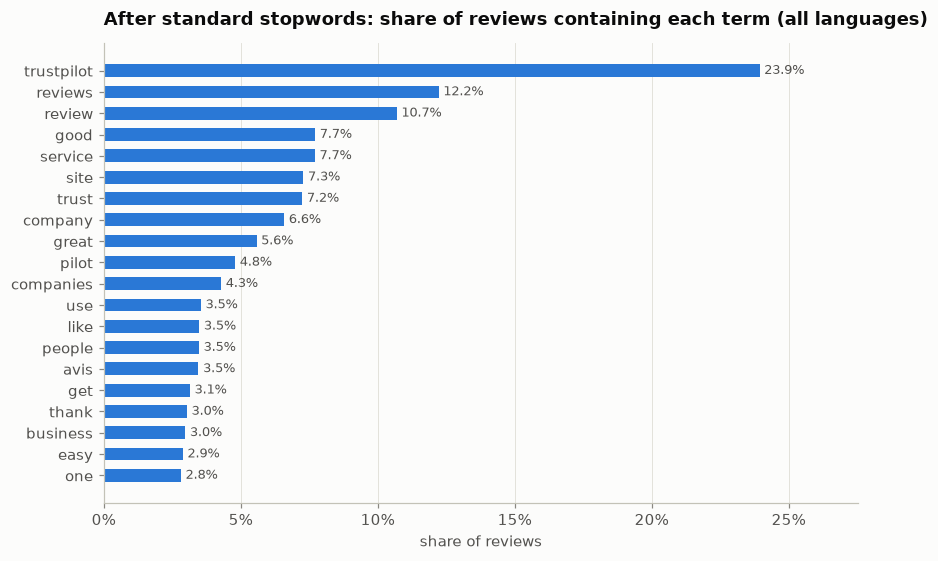

Share of tokens that are stopwords: {'en': np.float64(0.48), 'de': np.float64(0.47), 'fr': np.float64(0.4), 'da': np.float64(0.48)}


In [32]:
doc_terms = []
for lg, text in zip(lang, body):
    name = NLTK_LANG.get(lg)
    sw = set(stopwords.words(name)) if name else set()
    doc_terms.append({w.casefold() for w in TOKEN_RE.findall(text) if w.casefold() not in sw and len(w) > 2})
doc_freq = Counter(w for d in doc_terms for w in d)
hubs = pd.Series({w: n / len(doc_terms) for w, n in doc_freq.most_common(20)})
hbar(hubs, "After standard stopwords: share of reviews containing each term (all languages)",
     xlabel="share of reviews", pct=True, figsize=(8, 5.2))

tokens_per_lang = {lg: [w.casefold() for s in body[lang == lg] for w in TOKEN_RE.findall(s)] for lg in ["en", "de", "fr", "da"]}
print("Share of tokens that are stopwords:",
      {lg: round(np.mean([w in set(stopwords.words(NLTK_LANG[lg])) for w in toks]), 2) for lg, toks in tokens_per_lang.items()})

**Findings**
- **Standard stopwords are 40–50% of all tokens** in every language. They are easy to drop, but only with the *correct language list* (section 4).
- **Hub terms remain after stopword removal.** `trustpilot` is in **24% of all reviews**, and `reviews`/`review` in 12% and 11% (separately: inflection again). Then come `good`, `service`, `site`, `trust`, `company` (7–8% each), plus `pilot` (5%, the split brand) and `avis` (French "review").
- **Some words that stopword lists miss** behave like stopwords here (`get`, `one`, `like`, `use`).

**Implication:**
- **Add a domain stopword list** (brand, review/avis/bewertung/anmeldelse…, company, site, platform), or keep these as *edge attributes* rather than keyword nodes.
- **Apply document-frequency thresholds** when building keyword nodes, for example dropping terms in more than about 10% of reviews and terms seen fewer than about 3 times. Tune the thresholds after lemmatisation and brand canonicalisation.
- **Keep sentiment adjectives** out of topic nodes. They belong in a sentiment property.

*(Both approaches.)*

## 13. Same concept, many languages

Topic and theme nodes should be **language-independent**. Below, two concepts from notebook 01 (*review* and *fake*) are counted across languages.

In [33]:
concepts = {
    "review": r"\b(?:reviews?|reviewer\w*|avis|bewertung\w*|anmeldelse\w*|anmeldelser\w*|recensione|recensioni|recension\w*|beoordeling\w*|recensie\w*|reseñas?|opiniones?|omdöme\w*|anmeldelse\w*|avaliaç\w*|opini[oõ]\w*|arvostel\w*|отзыв\w*)\b",
    "fake": r"\b(?:fake\w*|false|faux|fausses?|gefälscht\w*|falsch\w*|falske?|falska|falso|falsi|falsas?|falsos|nep|neppe|vals\w*|фейк\w*|ложн\w*)\b",
    "scam / fraud": r"\b(?:scam\w*|fraud\w*|arnaque\w*|escroc\w*|betrug\w*|betrüger\w*|abzocke\w*|svindel\w*|bedrag\w*|oplichter\w*|truffa\w*|estafa\w*|golpe\w*|мошенн\w*)\b",
    "deleted / removed": r"\b(?:delet\w*|remov\w*|supprim\w*|gelöscht\w*|lösch\w*|entfernt\w*|slettet|slette\w*|fjern\w*|rimoss\w*|cancellat\w*|eliminad\w*|borrad\w*|verwijder\w*|raderad\w*|tagit bort|удал\w*)\b",
}
rows = []
for concept, pat in concepts.items():
    forms = Counter(w for s in body.str.lower() for w in re.findall(pat, s))
    hit = body.str.lower().str.contains(pat)
    rows.append((concept, len(forms), hit.sum(), lang[hit].nunique(), ", ".join(f"{w}({n})" for w, n in forms.most_common(14))))
pd.DataFrame(rows, columns=["concept", "distinct surface forms", "reviews", "languages", "top forms"])

,concept,distinct surface forms,reviews,languages,top forms
0,review,81,3281,14,"reviews(1974), review(1781), avis(538), bewertungen(343), recensioni(209), bewertung(208), anmeldelser(170), anmeldelse(152), recensione..."
1,fake,38,305,11,"fake(265), false(56), faux(26), falske(16), fakebewertungen(10), falsch(5), fakes(4), gefälschte(3), falsos(3), falschen(3), fausses(3),..."
2,scam / fraud,79,375,10,"scam(104), scammers(55), fraud(38), fraudulent(35), scammed(33), arnaque(21), scams(20), scamming(19), escrocs(14), arnaques(14), svinde..."
3,deleted / removed,57,674,10,"removed(271), remove(158), deleted(88), delete(56), gelöscht(55), removing(49), fjernet(33), slettet(30), löschen(21), deleting(20), rem..."


**Findings**
- **Each concept shows up as 38–81 surface forms across 10–14 languages** (table above). For example, *review* appears as `reviews`, `avis`, `bewertungen`, `recensioni`, `anmeldelser`, `opiniones`, `omdömen`, `beoordeling`…, and *fake* as `fake`, `false`, `faux`, `falske`, `gefälschte`, `Fakebewertungen`, `nep`…
- **English loanwords cross languages.** `fake` and `Fake-` compounds appear in 33 German reviews, and occasionally in Dutch, Italian, Swedish, Danish and French ones.
- **Within English alone, one concept has many forms**: `scam`, `scammers`, `scammed`, `scamming`, `fraud`, `fraudulent`.
- **Note that `false`/`falsch` are ambiguous** (wrong vs fake), so word-level mapping is lossy.

**Implication:** keyword nodes can stay language-specific, but **topic nodes need a language-independent layer**. Three ways to get it:
- **(a)** translate everything to English before keyword extraction;
- **(b)** map keywords to concepts with a curated multilingual dictionary or a multilingual embedding model;
- **(c)** have an LLM assign topics from a **fixed, closed list of topic IDs**, so it can't invent free-text topic names that vary between reviews.

This is the decision with the biggest impact on graph consistency. *(Both approaches.)*

## 14. Negation

In [34]:
neg_re = (r"\b(?:not|never|no|isn't|isn’t|don't|don’t|doesn't|doesn’t|wasn't|wasn’t|can't|can’t|cannot|nothing|hardly)\b"
          r"(?:\W+\w+){0,2}?\W+(good|great|helpful|trust\w*|reliable|honest|easy|recommend\w*|happy|fair|safe|genuine|useful)\b")
en_mask = lang == "en"
neg_hit = body[en_mask].str.contains(neg_re, case=False, regex=True)
print(f"English bodies with a negated positive word: {neg_hit.sum()}")
print("Their star distribution:", stars[en_mask][neg_hit].value_counts().sort_index().to_dict())
phr = Counter(m.group(0).lower() for s in body[en_mask][neg_hit] for m in re.finditer(neg_re, s, flags=re.I))
print("Most common:", ", ".join(f"'{p}' ({n})" for p, n in phr.most_common(12)))

pos_words = body[en_mask].str.contains(r"\b(?:good|trust\w*|honest|reliable|genuine)\b", case=False)
print(f"\n1★ English reviews containing good/trust/honest/reliable/genuine: {(pos_words & (stars[en_mask] == 1)).mean() / (stars[en_mask] == 1).mean():.0%}")

English bodies with a negated positive word: 260
Their star distribution: {1: 177, 2: 22, 3: 14, 4: 9, 5: 38}
Most common: 'not trust' (18), 'don't trust' (17), 'not happy' (17), 'not good' (12), 'not genuine' (8), 'no longer trust' (7), 'no good' (7), 'never trust' (7), 'not recommend' (7), 'cannot be trusted' (7), 'cannot trust' (6), 'not to be trusted' (6)

1★ English reviews containing good/trust/honest/reliable/genuine: 60%


**Findings**
- **260 English reviews negate a positive word**, mostly as `not trust`, `don't trust`, `not happy`, `not good`, `not genuine`, `cannot be trusted`. 68% of these are 1★.
- **Positive vocabulary is everywhere in negative reviews.** 60% of 1★ English reviews contain `good`, `trust`, `honest`, `reliable` or `genuine`, used negatively or about other things ("genuine reviews removed").

**Implication:**
- In a bag-of-keywords graph, **1★ reviews link to "trust" and "genuine"** just like 5★ reviews do, so **polarity must live on the edge** (a sentiment or negation flag) or in the review's star rating.
- **Do not fold negation into separate keyword nodes**, because `not_trust` and `trust` should stay the same concept.

*(Both approaches. Classic NLP needs explicit negation-scope handling; an LLM can return polarity per topic.)*

## 15. Low-content reviews

In [35]:
content_tokens = [len(d) for d in doc_terms]  # non-stopword tokens (>2 chars) per body, from section 12
ct = pd.Series(content_tokens)
bins = pd.cut(ct, [-1, 0, 1, 2, 5, 10_000], labels=["0", "1", "2", "3-5", "6+"])
summary = pd.DataFrame({"reviews": bins.value_counts().sort_index()})
summary["share"] = (summary["reviews"] / len(ct)).round(3)
summary["mean_stars"] = stars.groupby(bins, observed=True).mean().round(2)
summary

,reviews,share,mean_stars
0,28,0.003,4.50
1,365,0.036,4.68
2,1197,0.120,4.69
3-5,2550,0.255,4.57
6+,5860,0.586,3.78


In [36]:
print("Examples with zero content tokens:")
print(body[ct == 0].value_counts().head(15).to_string())
dup = (title.str.strip().str.casefold() + " || " + body.str.strip().str.casefold()).duplicated(keep=False)
print(f"\nReviews whose (title, body) is an exact duplicate of another review after casefolding: {dup.sum()}")

Examples with zero content tokens:
Text
👍👍👍👍👍👍👍👍👍👍👍👍👍👍👍👍             1
It was all so so             1
👍👍👍👍👍👍👍👍👍👍👍👍👍👍👍👍👍👍           1
Alles ok bis jetzt           1
Ok at de er til 👍            1
OK at I er her.              1
...................          1
$$$€€€$^%#%^$#%%=            1
A**************              1
👍👍👍👍👍😊                       1
👍👍👍👍👍👍👍👍👍👍👍👍👍👍               1
👍👍👍👍👍👍👍👍👍👍👍👍                 1
.........................    1
H h h h h h h h h h g        1
It is very OK!               1

Reviews whose (title, body) is an exact duplicate of another review after casefolding: 179


**Findings**
- **About 16% of reviews have two or fewer content words** after stopword removal ("Excellent service", "Top!", "👍👍👍"). They are overwhelmingly positive (mean about 4.7★). They link to one or two hub nodes at most, so they add volume but no structure.
- **28 bodies have no content at all**: emoji only, dots only, symbols (`$$$€€€`), keyboard mashing, or only stopwords and short words ("It is very OK!").
- **That last case shows a filter trap.** A minimum token length of 3 silently drops real two-letter content words such as `ok`. Use a short-word *allowlist* rather than a bare length filter.
- **Generic praise repeats word for word** across reviewers. 179 reviews duplicate another review's (title, body) after casefolding ("Excellent service", "Ottimo servizio").

**Implication:**
- **Keep these reviews as nodes**, since they matter for rating statistics.
- **Flag them** with `is_low_content` and attach their emoji or sentiment as an attribute.
- **Don't let them distort keyword co-occurrence or topic clustering.**
- **Don't deduplicate across reviewers.** Identical short texts are different people.

## 16. Summary: inconsistencies → candidate transformations

Order matters. Steps are listed in the order the preprocessing script should apply them. **Priority** is about impact on graph consistency: **H** = creates duplicate or fake nodes at scale, **M** = noticeable fragmentation, **L** = minor.

| # | Inconsistency | Prevalence (this sample) | Candidate transformation | Priority | Matters for |
|---|---|---|---|---|---|
| 1 | HTML entities (`&#233;`, `&#39;`, emoji `&#128077;`) | ~43% of bodies, ~21% of titles | `html.unescape` once, first | **H** | both |
| 2 | Whitespace: newlines, double spaces, NBSP, zero-width | ~1,900 / ~1,100 / 10 / 6 texts | collapse whitespace, drop zero-width, NBSP → space | M | classic |
| 3 | Title duplicates or truncates the body | 20% identical, 28% auto-truncated `…`, 24% prefix; only 23% of titles add words | use body (+ title only if it adds words), or dedupe edges per review; drop `…` fragments | **H** | both |
| 4 | Brand written 88 ways; "trust pilot" pollutes `trust` and creates `pilot` | brand in 24% of reviews; 64% of `trust` tokens are the brand | fuzzy brand regex → one canonical token (then domain stopword) | **H** | both |
| 5 | Language label unreliable for short texts; a few real mislabels; `no`/`nb`/`und` | 4.4% disagreement, almost all ≤12 words | keep label; re-detect long texts (brand masked); merge no/nb; fallback for `und` | M | classic (stemmers/stopwords), translation |
| 6 | Casing variants, shouting, Turkish `İ` | −14% vocabulary from casefold; ~1% all-caps | `casefold()`, strip U+0307; keep `caps_ratio` as attribute | **H** | classic |
| 7 | Apostrophe and quote variants (`'` `’` `´`); contractions | ’ in ~530 texts; 3+ spellings per contraction | map typographic quotes to ASCII; unify or expand contractions | M | classic |
| 8 | Ellipses, repeated `!!!`, elongations (`soooo`) | ~3,600 / ~630 / ~80 texts | normalise `…`/`...`, squeeze letter runs to 2; keep emphasis as attribute | L | classic |
| 9 | Compound spelling (`e-mail`/`email`, `web site`/`website`) | dozens of pairs | small compound map | L | classic |
| 10 | Emoji, skin-tone variants, emoji-only bodies | 710 texts; 11 emoji-only bodies | drop, or demojize to a sentiment attribute; never keyword nodes | M | both |
| 11 | URLs, IDs/phone numbers, dates, money, bare numbers | 163 / ~20 / ~40 / ~60 / ~1,100 texts | mask (`<URL>`, `<NUM>`, …) or drop; keep "N star(s)" as a phrase if wanted | M | both |
| 12 | Diacritics: missing-accent typos vs real minimal pairs | 100+ collisions in FR alone | **no blanket folding**; lexicon-based accent repair or lemmatise | M | classic |
| 13 | Misspellings (`reveiw`, `compny`, `Truspilot`) | 549 rare English forms | targeted fuzzy correction to a domain lexicon only; min-frequency for nodes | M | classic |
| 14 | Inflection; over-stemming (`integrity`≈`integration`); DE compounds | stemming −26 pts of vocabulary | lemmatise per language (spaCy/Stanza); readable labels; optional compound split | **H** | classic |
| 15 | Stopwords (40–50% of tokens) and domain hub terms | `trustpilot` 24%, `review(s)` 11–12% of reviews | language-specific stopwords + domain stopword list + doc-frequency caps | **H** | both |
| 16 | One concept, many languages | 38–81 forms × 10–14 languages per concept | language-independent topic layer: translation, multilingual mapping, or LLM with a closed topic list | **H** | both |
| 17 | Negation and irony | 260 EN reviews; 60% of 1★ EN use positive words | polarity on the Review→Keyword/Topic edge, not in the node | M | both |
| 18 | Low-content reviews | 16% with ≤2 content words; 28 with none | keep the review, flag `is_low_content`, exclude from co-occurrence | L | both |

### Questions to settle before writing the preprocessing script
1. **Topic layer.** Translate to English first, use a curated multilingual mapping, or use an LLM with a closed topic taxonomy (#16)? This decides most of the downstream steps.
2. **Title handling.** Use the body only, or body + title with per-review edge deduplication (#3)?
3. **Lemmatiser vs stemmer** (#14). spaCy has models for most of the top 10 languages here. Is adding them as a dependency OK?
4. **Brand and domain stopwords.** Drop them entirely, or keep a single `trustpilot` node (#4, #15)?
5. **Emoji and emphasis.** Discard them, or keep them as review-level sentiment attributes (#8, #10)?